In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import marching_cubes
import pyvista as pv
from scipy.spatial import KDTree


In [58]:
def load_density(filename, shape=(60, 60, 60), ntypes=2):
    with open(filename, "rb") as f:
        Dim = np.fromfile(f, dtype=np.int32, count=1)
        Nx = np.fromfile(f, dtype=np.int32, count=Dim[0])
        L = np.fromfile(f, dtype=np.float32, count=Dim[0])
        ntypes = np.fromfile(f, dtype=np.int32, count=1)[0]
        
        M = Nx[0] * Nx[1] * Nx[2]
        data = np.fromfile(f, dtype=np.float32, count=M * ntypes)
        density_grid = data[:M].reshape(shape)  # Assuming the first type for volume fraction
        return density_grid, Nx, L
    
    #Gaussian kernel for smoothing
def gaussian_kernel(sigma, truncate=3.0):
    """
    Returns a Gaussian kernel given a sigma value. The size of the kernel will be truncated
    based on the truncate value.
    """
    lw = int(truncate * sigma + 0.5)
    x = np.linspace(-lw, lw, 2*lw+1)
    y = np.linspace(-lw, lw, 2*lw+1)
    z = np.linspace(-lw, lw, 2*lw+1)

    x, y, z = np.meshgrid(x, y, z, indexing='ij')
    kernel = np.exp(-(x**2 + y**2 + z**2) / (2*sigma**2))
    kernel /= kernel.sum()
    return kernel

from scipy.ndimage import convolve



def gaussian_smoothing_grid_periodic_updated(grid_data, sigma):
    
    # Generate the Gaussian kernel
    kernel = gaussian_kernel(sigma)
    
    # Apply convolution using wrapped boundary conditions
    smoothed_grid = convolve(grid_data, kernel, mode='wrap')
    
    return smoothed_grid

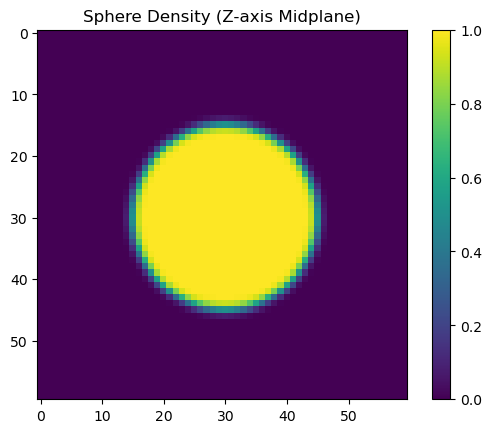

In [59]:
# Load sphere and cylinder density files
sphere_density, Nx, L = load_density("sphere_density_radius_15.0_sigma_1.0.bin")
cylinder_density, _, _ = load_density("cylinder_density_radius_15.0_sigma_1.0.bin")

plt.imshow(sphere_density[:, :, Nx[2] // 2], cmap="viridis")  # Middle slice in Z-axis
plt.colorbar()
plt.title("Sphere Density (Z-axis Midplane)")
plt.show()

# Smooth density grids
sigma = 1.0
sphere_density  = gaussian_smoothing_grid_periodic_updated(sphere_density, sigma)
cylinder_density  = gaussian_smoothing_grid_periodic_updated(cylinder_density, sigma)

# Run marching cubes for both shapes
sphere_verts_py, sphere_faces_py, _, _ = marching_cubes(sphere_density, level=0.50)
cylinder_verts_py, cylinder_faces_py, _, _ = marching_cubes(cylinder_density, level=0.50)

# Save Python results to CSV for later comparison with C++ results
np.savetxt("sphere_verts_py.csv", sphere_verts_py, delimiter=",")
np.savetxt("sphere_faces_py.csv", sphere_faces_py, fmt="%d", delimiter=",")
np.savetxt("cylinder_verts_py.csv", cylinder_verts_py, delimiter=",")
np.savetxt("cylinder_faces_py.csv", cylinder_faces_py, fmt="%d", delimiter=",")

In [60]:
# Load the .vtk file produced by your C++ code
sphere_contour = pv.read("sphere00_order_3_sigma_1.0_contour.vtk")  # Replace with your actual file path
cylinder_contour = pv.read("cylinder00_order_3_sigma_1.0_contour.vtk")  # Replace with your actual file path
# Extract vertices (points)
sphere_vertices = sphere_contour.points  # N x 3 array of vertex coordinates
cylinder_vertices = cylinder_contour.points  # N x 3 array of vertex coordinates
# Extract faces
# In PyVista, faces are stored as a 1D array where the first value in each face set
# indicates the number of vertices in the face (typically 3 for triangles)
sphere_faces = sphere_contour.faces.reshape(-1, 4)[:, 1:]  # Remove the leading count from each face
cylinder_faces = cylinder_contour.faces.reshape(-1, 4)[:, 1:]  # Remove the leading count from each face
# Save vertices and faces to CSV for direct comparison
np.savetxt("sphere_vertices_cpp.csv", sphere_vertices, delimiter=",")
np.savetxt("sphere_faces_cpp.csv", sphere_faces, fmt="%d", delimiter=",")
np.savetxt("cylinder_vertices_cpp.csv", cylinder_vertices, delimiter=",")
np.savetxt("cylinder_faces_cpp.csv", cylinder_faces, fmt="%d", delimiter=",")

# Compare number of vertices and faces between Python and C++ results
print("Sphere Vertices (Python):", sphere_verts_py.shape[0])
print("Sphere Vertices (C++):", sphere_vertices.shape[0])
print("Sphere Faces (Python):", sphere_faces_py.shape[0])
print("Sphere Faces (C++):", sphere_faces.shape[0])
print("Cylinder Vertices (Python):", cylinder_verts_py.shape[0])
print("Cylinder Vertices (C++):", cylinder_vertices.shape[0])
print("Cylinder Faces (Python):", cylinder_faces_py.shape[0])
print("Cylinder Faces (C++):", cylinder_faces.shape[0])


Sphere Vertices (Python): 4182
Sphere Vertices (C++): 4182
Sphere Faces (Python): 8360
Sphere Faces (C++): 8360
Cylinder Vertices (Python): 6960
Cylinder Vertices (C++): 6960
Cylinder Faces (Python): 13688
Cylinder Faces (C++): 13688


In [56]:
# Load vertices and faces from the Python Marching Cubes
sphere_vertices_py = np.loadtxt("sphere_verts_py.csv", delimiter=",")
sphere_faces_py = np.loadtxt("sphere_faces_py.csv", delimiter=",").astype(int)
cylinder_vertices_py = np.loadtxt("cylinder_verts_py.csv", delimiter=",")
cylinder_faces_py = np.loadtxt("cylinder_faces_py.csv", delimiter=",").astype(int)

# Load vertices and faces from the VTK (C++) Marching Cubes output
sphere_vertices_cpp = np.loadtxt("sphere_vertices_cpp.csv", delimiter=",")
sphere_faces_cpp = np.loadtxt("sphere_faces_cpp.csv", delimiter=",").astype(int)
cylinder_vertices_cpp = np.loadtxt("cylinder_vertices_cpp.csv", delimiter=",")
cylinder_faces_cpp = np.loadtxt("cylinder_faces_cpp.csv", delimiter=",").astype(int)
#cylinder_vertices_cpp = cylinder_vertices_cpp[:, [2, 1, 0]]  # Swap Y and Z if necessary

# Compare vertices using KDTree for nearest-neighbor matching
sphere_tree = KDTree(sphere_vertices_cpp)
sphere_distances, _ = sphere_tree.query(sphere_vertices_py)
cylinder_tree = KDTree(cylinder_vertices_cpp)
cylinder_distances, _ = cylinder_tree.query(cylinder_vertices_py)

print("Mean sphere vertex distance:", np.mean(sphere_distances))
print("Max sphere vertex distance:", np.max(sphere_distances))

print("Mean cylinder vertex distance:", np.mean(cylinder_distances))
print("Max cylinder vertex distance:", np.max(cylinder_distances))


# Compare faces by sorting vertex indices within each face
sphere_faces_py_sorted = np.sort(sphere_faces_py, axis=1)
sphere_faces_cpp_sorted = np.sort(sphere_faces_cpp, axis=1)
cylinder_faces_py_sorted = np.sort(cylinder_faces_py, axis=1)
cylinder_faces_cpp_sorted = np.sort(cylinder_faces_cpp, axis=1) 


# Count unmatched faces



Mean sphere vertex distance: 0.05081613043075479
Max sphere vertex distance: 0.2836475372314453
Mean cylinder vertex distance: 0.017699718475341797
Max cylinder vertex distance: 0.03620147705078125


/home/gabriel/anaconda3/envs/MDAnalysis/lib/python3.12/site-packages/pyvista/jupyter/notebook.py:37: UserWarning: Failed to use notebook backend: 

cannot import name 'vtk' from 'trame.widgets' (/home/gabriel/anaconda3/envs/MDAnalysis/lib/python3.12/site-packages/trame/widgets/__init__.py)

Falling back to a static output.
  warnings.warn(


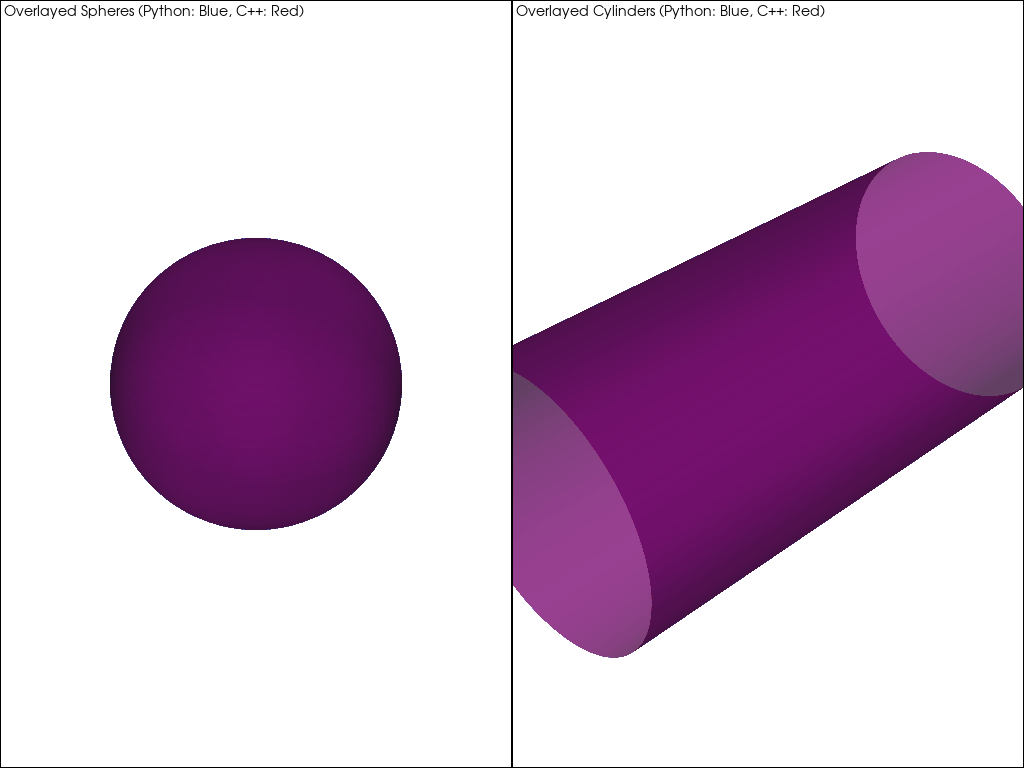

In [57]:


# Load Python and C++ results for sphere
vertices_sphere_py = np.loadtxt("sphere_verts_py.csv", delimiter=",")
faces_sphere_py = np.loadtxt("sphere_faces_py.csv", delimiter=",").astype(int)
vertices_sphere_cpp = np.loadtxt("sphere_vertices_cpp.csv", delimiter=",")
faces_sphere_cpp = np.loadtxt("sphere_faces_cpp.csv", delimiter=",").astype(int)

# Load Python and C++ results for cylinder
vertices_cylinder_py = np.loadtxt("cylinder_verts_py.csv", delimiter=",")
faces_cylinder_py = np.loadtxt("cylinder_faces_py.csv", delimiter=",").astype(int)
vertices_cylinder_cpp = np.loadtxt("cylinder_vertices_cpp.csv", delimiter=",")
faces_cylinder_cpp = np.loadtxt("cylinder_faces_cpp.csv", delimiter=",").astype(int)

# Convert face arrays for PyVista
# PyVista expects faces in the format [n_points, p1, p2, ..., pN]
faces_sphere_py = np.hstack([np.full((faces_sphere_py.shape[0], 1), 3), faces_sphere_py])
faces_sphere_cpp = np.hstack([np.full((faces_sphere_cpp.shape[0], 1), 3), faces_sphere_cpp])
faces_cylinder_py = np.hstack([np.full((faces_cylinder_py.shape[0], 1), 3), faces_cylinder_py])
faces_cylinder_cpp = np.hstack([np.full((faces_cylinder_cpp.shape[0], 1), 3), faces_cylinder_cpp])

# Create PolyData meshes for each
mesh_sphere_py = pv.PolyData(vertices_sphere_py, faces_sphere_py)
mesh_sphere_cpp = pv.PolyData(vertices_sphere_cpp, faces_sphere_cpp)
mesh_cylinder_py = pv.PolyData(vertices_cylinder_py, faces_cylinder_py)
mesh_cylinder_cpp = pv.PolyData(vertices_cylinder_cpp, faces_cylinder_cpp)
#mesh_cylinder_cpp.rotate_z(90)

# Set up PyVista plotting
plotter = pv.Plotter(shape=(1, 2))  # 1x2 grid for sphere and cylinder

# Add the meshes
plotter.subplot(0, 0)
plotter.add_mesh(mesh_sphere_py, color="blue", opacity=0.5, label="Sphere (Python)")
plotter.add_mesh(mesh_sphere_cpp, color="red", opacity=0.5, label="Sphere (C++)")
plotter.add_text("Overlayed Spheres (Python: Blue, C++: Red)", font_size=10)

plotter.subplot(0, 1)
plotter.add_mesh(mesh_cylinder_py, color="blue", opacity=0.5, label="Cylinder (Python)")
plotter.add_mesh(mesh_cylinder_cpp, color="red", opacity=0.5, label="Cylinder (C++)")
plotter.add_text("Overlayed Cylinders (Python: Blue, C++: Red)", font_size=10)
plotter.camera.position = (100, 100, 100)  # Adjust to zoom out further, this is just an example
plotter.camera.focal_point = (0, 0, 0)
plotter.camera.view_up = (0, 1, 0)

plotter.link_views()  # Link views so all are synchronized
plotter.view_isometric()  # Set an isometric view for all subplots
plotter.show()
